<a href="https://colab.research.google.com/github/tuanmin-27/Autoencoder/blob/main/Autoencoder_with_rbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [ ]:
!pip install torch torchvision matplotlib --quiet

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

config

In [ ]:
SEED = 0
BATCH = 128
LR_RBM = 0.03
AE_SIZES = (784, 1000, 500, 250, 30)
STEPS_RBM1 = 800
STEPS_RBM2 = 800
STEPS_RBM3 = 800
STEPS_RBM4 = 800
EPOCHS_AE = 30

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

torch.manual_seed(SEED)

Using device: cuda


*dataset* MNIST

In [ ]:
def flatten(x):
    return x.view(-1)   # 28x28 => 784

tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(flatten)
])

train_ds = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=tfm
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

print("Train size:", len(train_ds))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 521kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.71MB/s]


Train size: 60000


RBM

In [ ]:
class BernoulliRBM(nn.Module):

    def __init__(self, n_vis, n_hid):
        super().__init__()
        self.n_vis = n_vis
        self.n_hid = n_hid

        # W: [n_vis, n_hid], bv: [n_vis], bh: [n_hid]
        self.W = nn.Parameter(0.01 * torch.randn(n_vis, n_hid))
        self.bv = nn.Parameter(torch.zeros(n_vis))
        self.bh = nn.Parameter(torch.zeros(n_hid))

    def p_h_given_v(self, v):
        # v: [B, n_vis] -> p(h=1|v): [B, n_hid]
        return torch.sigmoid(v @ self.W + self.bh)

    def p_v_given_h(self, h):
        # h: [B, n_hid] -> p(v=1|h): [B, n_vis]
        return torch.sigmoid(h @ self.W.t() + self.bv)

    def cd1_step(self, v0):
        # ---- Positive phase ----
        ph0 = self.p_h_given_v(v0)              # [B, n_hid]
        h0 = torch.bernoulli(ph0)               # sample

        # ---- Negative phase ----
        pv1 = self.p_v_given_h(h0)              # [B, n_vis]
        v1 = torch.bernoulli(pv1)               # sample
        ph1 = self.p_h_given_v(v1)              # [B, n_hid]

        # Statistics
        pos = v0.t() @ ph0    # [n_vis, n_hid]
        neg = v1.t() @ ph1    # [n_vis, n_hid]

        return pos, neg, v0, pv1, ph0, ph1

train_rbm

In [ ]:
def train_rbm(rbm, loader, steps=800, lr=0.03, name="RBM"):
    rbm.to(DEVICE)
    opt = optim.SGD(rbm.parameters(), lr=lr)

    it = 0
    print(f"Training {name} ...")
    while it < steps:
      for x, _ in loader:
          v0 = x.to(DEVICE, non_blocking=True)

          # CD-1
          with torch.no_grad():
              pos, neg, v0, pv1, ph0, ph1 = rbm.cd1_step(v0)

          B = v0.size(0)
          opt.zero_grad(set_to_none=True)

          rbm.W.grad  = - (pos - neg) / B
          rbm.bv.grad = - (v0 - pv1).mean(dim=0)
          rbm.bh.grad = - (ph0 - ph1).mean(dim=0)

          opt.step()

          if it % 50 == 0:
              with torch.no_grad():
                  recon_bce = F.binary_cross_entropy(pv1, v0, reduction="mean").item()
              print(f"[{name}] step {it:4d}/{steps} | recon_BCE = {recon_bce:.4f}")

          it += 1
          if it >= steps:
              break

    print(f"Finished {name}.")
    return rbm

transform_with_rbm

In [ ]:
def transform_with_rbm(rbm, loader):
    rbm.eval()
    H = []

    with torch.no_grad():
        for x, _ in loader:
            v = x.to(DEVICE)
            ph = rbm.p_h_given_v(v)   # [B, n_hidden]
            H.append(ph.cpu())

    H = torch.cat(H, dim=0)
    print("Hidden feature shape:", H.shape)
    return H

Autoencoder

In [ ]:
class AE(nn.Module):
    def __init__(self, sizes=(784, 1000, 500, 250, 30)):
        super().__init__()
        d, h1, h2, h3, code = sizes

        # Encoder
        self.enc1 = nn.Linear(d,   h1)
        self.enc2 = nn.Linear(h1,  h2)
        self.enc3 = nn.Linear(h2,  h3)
        self.enc4 = nn.Linear(h3,  code)   # code layer (linear)

        # Decoder
        self.dec4 = nn.Linear(code, h3)
        self.dec3 = nn.Linear(h3,   h2)
        self.dec2 = nn.Linear(h2,   h1)
        self.dec1 = nn.Linear(h1,   d)

        # Hidden logistic, code linear, output logistic
        self.act = nn.Sigmoid()
        self.out = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        z1 = self.act(self.enc1(x))   # 1000 logistic
        z2 = self.act(self.enc2(z1))  # 500 logistic
        z3 = self.act(self.enc3(z2))  # 250 logistic
        code = self.enc4(z3)          # 30 linear

        # Decoder
        y3 = self.act(self.dec4(code))
        y2 = self.act(self.dec3(y3))
        y1 = self.act(self.dec2(y2))
        y  = self.out(self.dec1(y1))  # logistic output

        return y, code

initialize_ae_from_rbms

In [ ]:
def initialize_ae_from_rbms(ae, rbms):
    rbm1, rbm2, rbm3, rbm4 = rbms

    with torch.no_grad():
        # encoder 1: 784 -> 1000
        ae.enc1.weight.copy_(rbm1.W.t())
        ae.enc1.bias.copy_(rbm1.bh)

        # encoder 2: 1000 -> 500
        ae.enc2.weight.copy_(rbm2.W.t())
        ae.enc2.bias.copy_(rbm2.bh)

        # encoder 3: 500 -> 250
        ae.enc3.weight.copy_(rbm3.W.t())
        ae.enc3.bias.copy_(rbm3.bh)

        # encoder 4 (code): 250 -> 30
        ae.enc4.weight.copy_(rbm4.W.t())
        ae.enc4.bias.copy_(rbm4.bh)

        # decoder 4: 30 -> 250
        ae.dec4.weight.copy_(rbm4.W)
        ae.dec4.bias.copy_(rbm4.bv)

        # decoder 3: 250 -> 500
        ae.dec3.weight.copy_(rbm3.W)
        ae.dec3.bias.copy_(rbm3.bv)

        # decoder 2: 500 -> 1000
        ae.dec2.weight.copy_(rbm2.W)
        ae.dec2.bias.copy_(rbm2.bv)

        # decoder 1: 1000 -> 784
        ae.dec1.weight.copy_(rbm1.W)
        ae.dec1.bias.copy_(rbm1.bv)

    print("Initialized DeepAE from 4 stacked RBMs.")

Train RBM1 & RBM2

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

def make_loader_from_tensor(tensor, batch_size=BATCH):
    ds = TensorDataset(tensor, torch.zeros(len(tensor)))
    return DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0)

# ---------- RBM1: 784 -> 1000 ----------
rbm1 = BernoulliRBM(784, 1000)
rbm1 = train_rbm(rbm1, train_loader, steps=STEPS_RBM1, lr=LR_RBM, name="RBM1 784->1000")

# Features for RBM2
H1 = transform_with_rbm(rbm1, train_loader)         # [N,1000]
loader2 = make_loader_from_tensor(H1)

# ---------- RBM2: 1000 -> 500 ----------
rbm2 = BernoulliRBM(1000, 500)
rbm2 = train_rbm(rbm2, loader2, steps=STEPS_RBM2, lr=LR_RBM, name="RBM2 1000->500")

# Features for RBM3
H2 = transform_with_rbm(rbm2, loader2)             # [N,500]
loader3 = make_loader_from_tensor(H2)

# ---------- RBM3: 500 -> 250 ----------
rbm3 = BernoulliRBM(500, 250)
rbm3 = train_rbm(rbm3, loader3, steps=STEPS_RBM3, lr=LR_RBM, name="RBM3 500->250")

# Features for RBM4
H3 = transform_with_rbm(rbm3, loader3)             # [N,250]
loader4 = make_loader_from_tensor(H3)

# ---------- RBM4: 250 -> 30 ----------
rbm4 = BernoulliRBM(250, 30)
rbm4 = train_rbm(rbm4, loader4, steps=STEPS_RBM4, lr=LR_RBM, name="RBM4 250->30")

rbms = [rbm1, rbm2, rbm3, rbm4]


Training RBM1 784->1000 ...
[RBM1 784->1000] step    0/800 | recon_BCE = 0.6966
[RBM1 784->1000] step   50/800 | recon_BCE = 0.2524
[RBM1 784->1000] step  100/800 | recon_BCE = 0.2205
[RBM1 784->1000] step  150/800 | recon_BCE = 0.2027
[RBM1 784->1000] step  200/800 | recon_BCE = 0.1972
[RBM1 784->1000] step  250/800 | recon_BCE = 0.1835
[RBM1 784->1000] step  300/800 | recon_BCE = 0.1763
[RBM1 784->1000] step  350/800 | recon_BCE = 0.1702
[RBM1 784->1000] step  400/800 | recon_BCE = 0.1653
[RBM1 784->1000] step  450/800 | recon_BCE = 0.1575
[RBM1 784->1000] step  500/800 | recon_BCE = 0.1552
[RBM1 784->1000] step  550/800 | recon_BCE = 0.1482
[RBM1 784->1000] step  600/800 | recon_BCE = 0.1503
[RBM1 784->1000] step  650/800 | recon_BCE = 0.1417
[RBM1 784->1000] step  700/800 | recon_BCE = 0.1422
[RBM1 784->1000] step  750/800 | recon_BCE = 0.1481
Finished RBM1 784->1000.
Hidden feature shape: torch.Size([60000, 1000])
Training RBM2 1000->500 ...
[RBM2 1000->500] step    0/800 | recon_

initialize AE from RBM + fine-tune end-to-end

In [ ]:

# N_CG = 10000

loss_history = []
# X_cg_list = []
# for i in range(N_CG):
#     x, _ = train_ds[i]
#     X_cg_list.append(x)

# X_cg = torch.stack(X_cg_list, dim=0).to(DEVICE)  # [N_CG, 784]
# print("X_cg shape:", X_cg.shape)

X_full = torch.stack([x for x, _ in train_ds], dim=0).to(DEVICE)
print("X_full shape:", X_full.shape)

import torch.nn as nn
import torch.optim as optim

def fine_tune_with_cg(model, X, epochs=20):
    model.to(DEVICE)
    model.train()

    criterion = nn.BCELoss()


    optimizer = optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=20,
        history_size=50
    )

    for epoch in range(1, epochs + 1):
        def closure():
            optimizer.zero_grad()
            y_hat, _ = model(X)
            loss = criterion(y_hat, X)
            loss.backward()
            return loss

        loss = optimizer.step(closure)
        loss_history.append(loss)
        print(f"[CG] epoch {epoch}/{epochs} | loss = {loss.item():.6f}")

    return model

deep_ae = AE(AE_SIZES).to(DEVICE)
initialize_ae_from_rbms(deep_ae, rbms)

# deep_ae = fine_tune_with_cg(deep_ae, X_cg, epochs=20)
deep_ae = fine_tune_with_cg(deep_ae, X_full, epochs=EPOCHS_AE)

X_full shape: torch.Size([60000, 784])
Initialized DeepAE from 4 stacked RBMs.
[CG] epoch 1/30 | loss = 0.279139
[CG] epoch 2/30 | loss = 0.165715
[CG] epoch 3/30 | loss = 0.155824
[CG] epoch 4/30 | loss = 0.150241
[CG] epoch 5/30 | loss = 0.145170
[CG] epoch 6/30 | loss = 0.142540
[CG] epoch 7/30 | loss = 0.139993
[CG] epoch 8/30 | loss = 0.137687
[CG] epoch 9/30 | loss = 0.136046
[CG] epoch 10/30 | loss = 0.134551
[CG] epoch 11/30 | loss = 0.133355
[CG] epoch 12/30 | loss = 0.132194
[CG] epoch 13/30 | loss = 0.131196
[CG] epoch 14/30 | loss = 0.130327
[CG] epoch 15/30 | loss = 0.129444
[CG] epoch 16/30 | loss = 0.128646
[CG] epoch 17/30 | loss = 0.127913
[CG] epoch 18/30 | loss = 0.127353
[CG] epoch 19/30 | loss = 0.126754
[CG] epoch 20/30 | loss = 0.126258
[CG] epoch 21/30 | loss = 0.125814
[CG] epoch 22/30 | loss = 0.125203
[CG] epoch 23/30 | loss = 0.124762
[CG] epoch 24/30 | loss = 0.124209
[CG] epoch 25/30 | loss = 0.123718
[CG] epoch 26/30 | loss = 0.123348
[CG] epoch 27/30 | l

PLOT

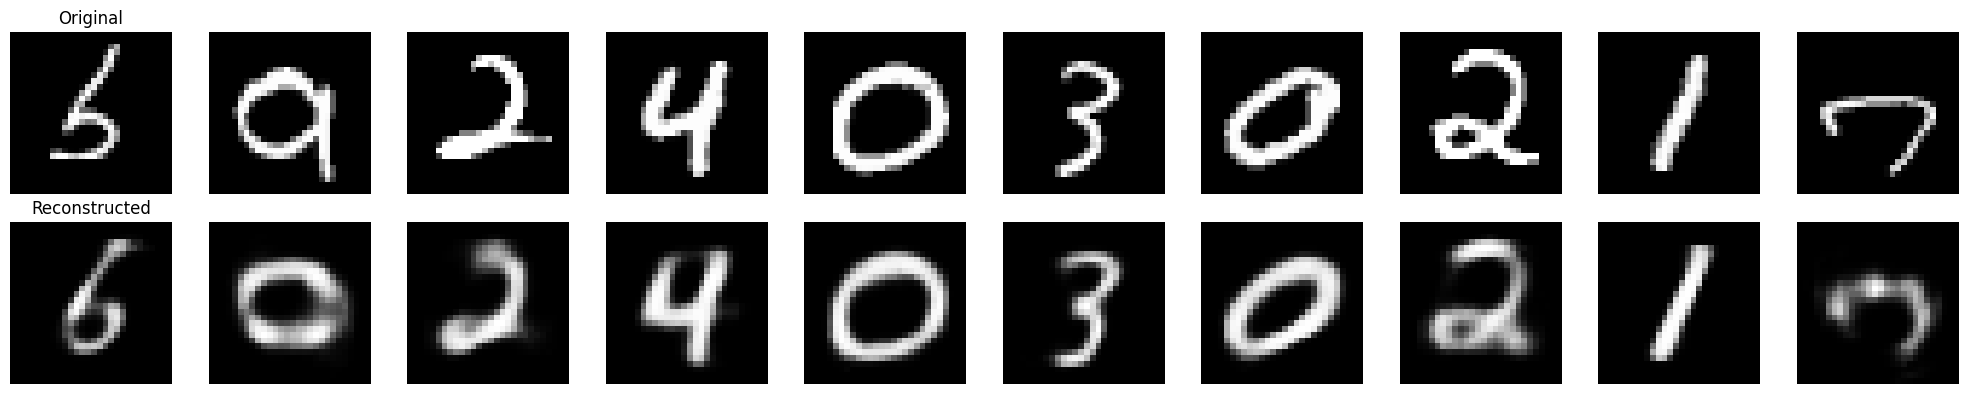

In [ ]:
deep_ae.eval()
with torch.no_grad():
    batch = next(iter(train_loader))[0].to(DEVICE)
    recon, _ = deep_ae(batch)

batch = batch.cpu().view(-1, 28, 28)
recon = recon.cpu().view(-1, 28, 28)

n = 10
plt.figure(figsize=(2*n, 4))

for i in range(n):
    # Ảnh gốc
    plt.subplot(2, n, i + 1)
    plt.imshow(batch[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    # Ảnh tái tạo
    plt.subplot(2, n, n + i + 1)
    plt.imshow(recon[i], cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Reconstructed")

plt.tight_layout()
plt.show()

plot losses

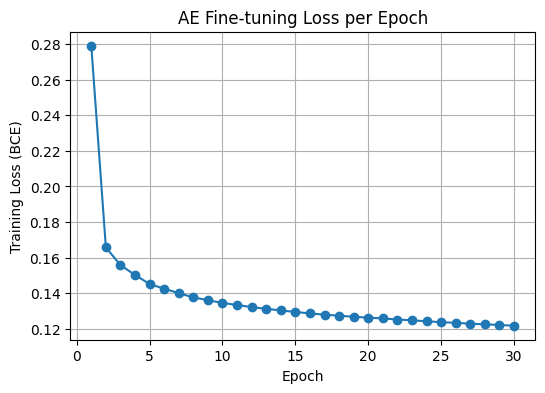

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
# Convert CUDA tensors to CPU scalars for plotting
plot_losses = [loss.cpu().item() for loss in loss_history]
plt.plot(range(1, len(plot_losses) + 1), plot_losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Loss (BCE)")
plt.title("AE Fine-tuning Loss per Epoch")
plt.grid(True)
plt.show()

Pca with base line code mse

In [ ]:
import argparse
import time
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

import joblib
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_olivetti_faces, fetch_openml
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

AE_CODE_DIM = 30  # matches AUTO1.AE_SIZES code dimension
RANDOM_STATE = 0  # align with autoencoder experiments
ARTIFACTS_DIR = "artifacts"
DEFAULT_GRID_COMPONENTS = (10, 20, 30, 40, 50, 60, 70, 80, 90, 100)
DEFAULT_SCALE_METHOD = "minmax"
DEBUG_PLOTS = False


def ensure_artifacts_dir(path: str | Path = ARTIFACTS_DIR) -> Path:
    """Create the artifacts directory if needed and return its Path."""
    artifacts_path = Path(path)
    artifacts_path.mkdir(parents=True, exist_ok=True)
    return artifacts_path


def load_dataset(
    name: str = "mnist", max_samples: Optional[int] = None, random_state: int = RANDOM_STATE
) -> Tuple[np.ndarray, np.ndarray, Dict[str, object]]:

    name = name.lower()
    rng = np.random.default_rng(random_state)

    if name == "mnist":
        mnist = fetch_openml("mnist_784", version=1, as_frame=False)
        X = mnist["data"].astype(np.float32)
        y = mnist["target"].astype(np.int64)
        meta = {"name": "mnist", "n_features": X.shape[1], "n_classes": 10, "image_shape": (28, 28)}
    elif name == "olivetti_faces":
        # Olivetti faces appear in the original paper; we flatten each 64x64 grayscale image.
        faces = fetch_olivetti_faces()
        X = faces.images.reshape(len(faces.images), -1).astype(np.float32)
        y = faces.target.astype(np.int64)
        meta = {"name": "olivetti_faces", "n_features": X.shape[1], "n_classes": len(np.unique(y)), "image_shape": (64, 64)}
    elif name == "fashion_mnist":
        # Extension beyond the original paper: Fashion-MNIST to test generalization.
        fashion = fetch_openml("Fashion-MNIST", version=1, as_frame=False)
        X = fashion["data"].astype(np.float32)
        y = fashion["target"].astype(np.int64)
        meta = {"name": "fashion_mnist", "n_features": X.shape[1], "n_classes": 10, "image_shape": (28, 28)}
    else:
        raise ValueError(f"Unsupported dataset '{name}'.")

    if max_samples is not None and max_samples < len(X):
        indices = rng.choice(len(X), size=max_samples, replace=False)
        X = X[indices]
        y = y[indices]

    return X, y, meta


def load_mnist(max_samples: Optional[int] = None, random_state: int = RANDOM_STATE) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convenience wrapper for MNIST to maintain compatibility with earlier code.

    Prefer load_dataset("mnist", ...) if you also need metadata to align with the
    autoencoder experiments.
    """
    X, y, _ = load_dataset(name="mnist", max_samples=max_samples, random_state=random_state)
    return X, y


def split_and_scale(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float,
    random_state: int,
    scale_method: str = DEFAULT_SCALE_METHOD,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, Optional[StandardScaler]]:
    """
    Split into train/test (stratified when labels are available) and scale features.

    This mirrors the preprocessing used by the deep autoencoder so PCA and the autoencoder
    see the same data distribution for fair comparisons.
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    if scale_method == "minmax":
        # Autoencoder expects inputs in [0, 1]; keep PCA input consistent by default.
        scaler = None
        scale_factor = 255.0 if X_train.max() > 1.0 else 1.0
        X_train_scaled = X_train / scale_factor
        X_test_scaled = X_test / scale_factor
    elif scale_method == "standard":
        scaler = StandardScaler()
        scaler.fit(X_train)
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test)
    else:
        raise ValueError("scale_method must be 'minmax' or 'standard'")
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler


def pca_transform(
    X_train: np.ndarray, X_test: np.ndarray, n_components: int
) -> Tuple[np.ndarray, np.ndarray, PCA]:
    """Fit PCA on the training data and transform both train and test splits."""
    pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)
    return X_train_pca, X_test_pca, pca


def evaluate_random_forest_accuracy(
    X_train_features: np.ndarray,
    X_test_features: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    random_state: int = RANDOM_STATE,
) -> float:
    """Train a RandomForestClassifier on provided features and return test accuracy."""
    clf = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
    clf.fit(X_train_features, y_train)
    y_pred = clf.predict(X_test_features)
    return accuracy_score(y_test, y_pred)


def run_pca_rf_experiment(
    X_train_scaled: np.ndarray,
    X_test_scaled: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    n_components: int,
    artifacts_dir: Optional[Path | str] = ARTIFACTS_DIR,
    scaler: Optional[StandardScaler] = None,
    scale_method: str = DEFAULT_SCALE_METHOD,
) -> dict:
    """Fit PCA(n_components), train RandomForest on PCA features, and log metrics."""
    t0 = time.time()
    X_train_pca, X_test_pca, pca_model = pca_transform(X_train_scaled, X_test_scaled, n_components=n_components)

    clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    clf.fit(X_train_pca, y_train)
    train_time = time.time() - t0

    y_pred = clf.predict(X_test_pca)
    accuracy = accuracy_score(y_test, y_pred)

    X_test_recon_scaled = pca_model.inverse_transform(X_test_pca)
    if scale_method == "standard" and scaler is not None:
        # Compare reconstructions in the original pixel space for fair AE vs PCA comparison.
        X_test_recon = scaler.inverse_transform(X_test_recon_scaled)
        X_test_original = scaler.inverse_transform(X_test_scaled)
    else:
        X_test_recon = X_test_recon_scaled
        X_test_original = X_test_scaled
    recon_mse = mean_squared_error(X_test_original, X_test_recon)
    cum_explained_var = float(pca_model.explained_variance_ratio_.sum())

    metrics = {
        "label": f"pca_{n_components}",
        "n_components": n_components,
        "accuracy": accuracy,
        "train_time": train_time,
        "cum_explained_var": cum_explained_var,
        "recon_mse": recon_mse,
        "scale_method": scale_method,
    }

    if artifacts_dir is not None:
        artifacts_path = ensure_artifacts_dir(artifacts_dir)
        joblib.dump(pca_model, artifacts_path / f"pca_k_{n_components}.joblib")
        np.save(artifacts_path / f"Xte_recon_k{n_components}.npy", X_test_recon[:100])
        maybe_plot_reconstructions(X_test_original, X_test_recon, artifacts_path, suffix=f"k{n_components}")

    if accuracy < 0.5:
        print(f"[WARN] PCA-{n_components} accuracy {accuracy:.4f} is unusually low (random guess ~0.10).")
    return metrics


def run_component_grid(
    X_train_scaled: np.ndarray,
    X_test_scaled: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    components: Sequence[int],
    artifacts_dir: Path | str = ARTIFACTS_DIR,
    save_csv: bool = True,
    generate_plots: bool = True,
    scaler: Optional[StandardScaler] = None,
    scale_method: str = DEFAULT_SCALE_METHOD,
) -> pd.DataFrame:
    """Run PCA + RandomForest experiments over multiple component counts.

    Saves a CSV with columns: n_components, accuracy, train_time, cum_explained_var, recon_mse.
    """
    records = []
    artifacts_path = ensure_artifacts_dir(artifacts_dir)
    for k in components:
        metrics = run_pca_rf_experiment(
            X_train_scaled,
            X_test_scaled,
            y_train,
            y_test,
            n_components=k,
            artifacts_dir=artifacts_path,
            scaler=scaler,
            scale_method=scale_method,
        )
        records.append(
            {
                "n_components": metrics["n_components"],
                "accuracy": metrics["accuracy"],
                "train_time": metrics["train_time"],
                "cum_explained_var": metrics["cum_explained_var"],
                "recon_mse": metrics["recon_mse"],
                "scale_method": metrics["scale_method"],
            }
        )
        print(
            f"k={k}: acc={metrics['accuracy']:.4f}, "
            f"cum_var={metrics['cum_explained_var']:.4f}, mse={metrics['recon_mse']:.6f}"
        )

    df = pd.DataFrame(records)
    if save_csv:
        csv_path = artifacts_path / "pca_grid_results.csv"
        df.to_csv(csv_path, index=False)
    if generate_plots and len(df) > 0:
        generate_grid_plots(df, artifacts_path)
    return df


def generate_grid_plots(df: pd.DataFrame, artifacts_dir: Path | str) -> None:
    """Save plots of accuracy, cumulative variance, and reconstruction MSE vs n_components."""
    import matplotlib.pyplot as plt

    artifacts_path = ensure_artifacts_dir(artifacts_dir)
    df_sorted = df.sort_values("n_components")

    plt.figure(figsize=(6, 4))
    plt.plot(df_sorted["n_components"], df_sorted["accuracy"], marker="o")
    plt.xlabel("n_components")
    plt.ylabel("Test accuracy")
    plt.title("PCA + RF accuracy vs components")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(artifacts_path / "pca_accuracy_vs_k.png")
    plt.close()

    plt.figure(figsize=(6, 4))
    plt.plot(df_sorted["n_components"], df_sorted["cum_explained_var"], marker="o")
    plt.xlabel("n_components")
    plt.ylabel("Cumulative explained variance")
    plt.title("Explained variance vs components")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(artifacts_path / "pca_cum_var_vs_k.png")
    plt.close()

    plt.figure(figsize=(6, 4))
    plt.plot(df_sorted["n_components"], df_sorted["recon_mse"], marker="o")
    plt.xlabel("n_components")
    plt.ylabel("Reconstruction MSE (input scale)")
    plt.title("Reconstruction error vs components")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(artifacts_path / "pca_recon_mse_vs_k.png")
    plt.close()


def parse_component_list(component_str: str) -> List[int]:
    """Parse a comma-separated component list string into integers."""
    cleaned = component_str.strip()
    if not cleaned:
        return []
    return [int(value) for value in cleaned.split(",") if value.strip()]


def maybe_plot_reconstructions(
    original_scaled: np.ndarray,
    reconstructed_scaled: np.ndarray,
    artifacts_dir: Path,
    suffix: str = "",
    num_images: int = 10,
    show: bool = True,
    save: bool = True,
) -> None:
    """Optionally save debug plots comparing original vs reconstructed digits."""
    if not DEBUG_PLOTS:
        return

    import matplotlib.pyplot as plt

    count = min(num_images, len(original_scaled), len(reconstructed_scaled))
    fig, axes = plt.subplots(2, count, figsize=(1.5 * count, 3))
    for idx in range(count):
        axes[0, idx].imshow(original_scaled[idx].reshape(28, 28), cmap="gray")
        axes[0, idx].axis("off")
        axes[1, idx].imshow(reconstructed_scaled[idx].reshape(28, 28), cmap="gray")
        axes[1, idx].axis("off")

    axes[0, 0].set_ylabel("Original", fontsize=10)
    axes[1, 0].set_ylabel("Reconstructed", fontsize=10)
    plt.tight_layout()
    suffix = f"_{suffix}" if suffix else ""
    plt.savefig(Path(artifacts_dir) / f"pca_recon_comparison{suffix}.png")
    plt.close()


def run_experiments(
    test_size: float,
    n_components: int,
    grid_components: Sequence[int],
    max_samples: Optional[int],
    dataset: str,
    scale_method: str = DEFAULT_SCALE_METHOD,
) -> tuple[pd.DataFrame, Path, Optional[float], Dict[str, object]]:
    """
    Run raw baseline, a single PCA baseline, and optional PCA grid experiments.

    For fairness with the deep autoencoder experiments, the same dataset and
    preprocessing (flattening + scaling) are used here. When possible, reuse
    the same loader and train/test split strategy across PCA and autoencoder runs.
    """
    artifacts_path = ensure_artifacts_dir(ARTIFACTS_DIR)

    # Expectations: random guess on 10 classes ~0.10; RandomForest on scaled pixels should be far higher on MNIST.
    X, y, meta = load_dataset(name=dataset, max_samples=max_samples, random_state=RANDOM_STATE)
    X_train_scaled, X_test_scaled, y_train, y_test, scaler = split_and_scale(
        X, y, test_size=test_size, random_state=RANDOM_STATE, scale_method=scale_method
    )

    summary_records = []

    raw_accuracy = evaluate_random_forest_accuracy(X_train_scaled, X_test_scaled, y_train, y_test)
    if meta.get("name") == "mnist":
        # MNIST expectations: RF on scaled pixels typically ~0.95-0.97; if low, something may be wrong.
        if raw_accuracy < 0.5:
            print(f"[WARN] Raw scaled RF accuracy {raw_accuracy:.4f} is very low (random guess ~0.10).")
        elif raw_accuracy < 0.8:
            print(f"[WARN] Raw scaled RF accuracy {raw_accuracy:.4f} is lower than expected (>~0.8).")
    summary_records.append(
        {
            "label": "raw_scaled",
            "n_components": None,
            "accuracy": raw_accuracy,
            "train_time": np.nan,
            "cum_explained_var": np.nan,
            "recon_mse": np.nan,
            "scale_method": scale_method,
        }
    )

    single_metrics = run_pca_rf_experiment(
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
        n_components=n_components,
        artifacts_dir=artifacts_path,
        scaler=scaler,
        scale_method=scale_method,
    )
    summary_records.append(single_metrics)

    grid_df = pd.DataFrame()
    if grid_components:
        grid_df = run_component_grid(
            X_train_scaled,
            X_test_scaled,
            y_train,
            y_test,
            components=grid_components,
            artifacts_dir=artifacts_path,
            save_csv=True,
            generate_plots=True,
            scaler=scaler,
            scale_method=scale_method,
        )
        grid_df["label"] = [f"pca_{k}" for k in grid_df["n_components"]]
        summary_records.extend(grid_df.to_dict(orient="records"))
        best_grid_acc = grid_df["accuracy"].max()
    else:
        best_grid_acc = None

    results_df = pd.DataFrame(summary_records)
    results_df.to_csv(artifacts_path / "pca_experiment_results.csv", index=False)

    # Sanity notes for readers:
    # - Explained variance should increase with k and approach 1.0 as k -> 784.
    # - Reconstruction MSE should decrease as k increases.
    # - Accuracy may rise then plateau; very small k (e.g., 10) is usually worse than larger k (e.g., 50-100) on MNIST.
    # - For Olivetti faces (paper comparison), k=30 is a natural reference point against the 30-dim autoencoder code.
    # - Fashion-MNIST (extension) should show similar qualitative trends but lower absolute accuracy.

    # Save scaler for reuse if desired
    joblib.dump(scaler, artifacts_path / "scaler.joblib")
    return results_df, artifacts_path / "pca_experiment_results.csv", best_grid_acc, meta


def parse_args() -> argparse.Namespace:
    """Parse CLI arguments for the PCA baseline experiments."""
    parser = argparse.ArgumentParser(description="PCA baselines for dimensionality reduction + classification.")
    parser.add_argument(
        "--dataset",
        type=str,
        default="mnist",
        choices=["mnist", "olivetti_faces", "fashion_mnist"],
        help="Which dataset to use for the PCA baseline.",
    )
    parser.add_argument("--test_size", type=float, default=0.2, help="Proportion of data used for testing.")
    parser.add_argument(
        "--n_components",
        type=int,
        default=AE_CODE_DIM,
        help="Number of PCA components for the main baseline.",
    )
    parser.add_argument(
        "--grid_components",
        type=str,
        default=",".join(map(str, DEFAULT_GRID_COMPONENTS)),
        help="Comma-separated list of PCA components for the grid experiment. Use empty string to skip.",
    )
    parser.add_argument(
        "--max_samples",
        type=int,
        default=None,
        help="Optional maximum number of total samples for quick debugging.",
    )
    parser.add_argument(
        "--scale_method",
        type=str,
        default=DEFAULT_SCALE_METHOD,
        choices=["minmax", "standard"],
        help="How to scale inputs before PCA. 'minmax' matches the autoencoder's [0,1] pixel scale.",
    )
    # Thêm args=[] vào bên trong ngoặc
    args = parser.parse_args(args=[])
    return args


def main() -> None:
    """Entry point: run baselines, optional grid search, and report metrics."""
    args = parse_args()
    grid_components = parse_component_list(args.grid_components)

    results_df, csv_path, best_grid_acc, meta = run_experiments(
        test_size=args.test_size,
        n_components=args.n_components,
        grid_components=grid_components,
        max_samples=args.max_samples,
        dataset=args.dataset,
        scale_method=args.scale_method,
    )

    display_cols = [
        "label",
        "n_components",
        "accuracy",
        "train_time",
        "cum_explained_var",
        "recon_mse",
        "scale_method",
    ]
    print("\nSummary results:")
    print(results_df[display_cols].to_string(index=False, na_rep="-"))

    dataset_name = meta.get("name", args.dataset)
    print(f"\nDataset: {dataset_name}")
    print(f"Raw scaled RF accuracy: {results_df.loc[results_df['label']=='raw_scaled', 'accuracy'].iat[0]:.4f}")
    print(f"PCA-{args.n_components} accuracy: {results_df.loc[results_df['label']==f'pca_{args.n_components}', 'accuracy'].iat[0]:.4f}")
    if best_grid_acc is not None:
        print(f"Best grid accuracy: {best_grid_acc:.4f}")
    print(f"Saved results to {csv_path}")

if __name__ == "__main__":
    main()


k=10: acc=0.9149, cum_var=0.4894, mse=0.034437
k=20: acc=0.9504, cum_var=0.6447, mse=0.023920
k=30: acc=0.9564, cum_var=0.7316, mse=0.018071
k=40: acc=0.9579, cum_var=0.7869, mse=0.014331
k=50: acc=0.9561, cum_var=0.8254, mse=0.011751
k=60: acc=0.9546, cum_var=0.8532, mse=0.009883
k=70: acc=0.9550, cum_var=0.8745, mse=0.008455
k=80: acc=0.9544, cum_var=0.8910, mse=0.007346
k=90: acc=0.9533, cum_var=0.9042, mse=0.006459
k=100: acc=0.9535, cum_var=0.9150, mse=0.005739

Summary results:
     label  n_components  accuracy  train_time  cum_explained_var  recon_mse scale_method
raw_scaled             -  0.972143           -                  -          -       minmax
    pca_30          30.0  0.956429   43.130627           0.731619   0.018071       minmax
    pca_10          10.0  0.914929   25.157088           0.489357   0.034437       minmax
    pca_20          20.0  0.950429   34.918937           0.644694   0.023920       minmax
    pca_30          30.0  0.956429   43.078409           0.73